# Why is Social recoverable under `default` priors?

**The puzzle.** In `final-tv-test-under-real-demo-data-roi-shape-coupling.ipynb`,
the `default` (uninformed) prior variant fails to recover `ec_m` and `roi_m`
for TV and Display, but recovers **all three** of Social's parameters --
`alpha_m`, `ec_m`, and `roi_m` -- with a posterior so tight it looks like a
different problem entirely:

| channel | true `ec_m` | `default` posterior | |
|---|---|---|---|
| TV | 11.069 | 4.739 (4.25-5.29) | miss |
| Display | 1.383 | 0.206 (0.10-0.24) | miss |
| Social | 0.297 | 0.276 (0.24-0.31) | **hit** |

That result holds in *both* media-sourcing scenarios, so it is not an artifact
of the TV/Social collinearity fixed in the parent notebook. If the informed
`ec_m`/`alpha_m` prior is the pitch, we need to know exactly why one channel
never needed it -- both because it sharpens the claim and because a reviewer
will ask.

**Three candidate explanations, tested in order:**

1. **Prior support** -- does Meridian's default `ec_m` prior even contain each
   channel's truth? (Section 2)
2. **Identifiability** -- does the *data* carry information about `ec_m`, and
   does that depend on where the channel sits on its own Hill curve?
   (Section 3)
3. **Likelihood corruption** -- for a channel whose truth the prior *does*
   support, what else can break recovery? (Section 5)

The short version, established below: **only explanation 2 is general.**
Social is recoverable because it is the one channel operating far enough up
its saturation curve for the data to locate the bend -- and that is precisely
the channel an informed prior was never needed for.

This notebook reuses the fits already saved by the parent scenario rather than
re-running MCMC, so it executes in seconds.

In [1]:
import json
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp

from data_simulator import SimulationConfig
from model_utils import build_real_augmented_input
from model_utils import ceiling_fraction_at_median
from model_utils import hill_value

FIT_DIR = 'fitted_models/roi_shape_coupling/swapped_social_ch1_impr'
CHANNEL_COLORS = {'TV': '#c1440e', 'Display': '#0b7285', 'Social': '#5f3dc4'}

## 1. Rebuild the scenario and load the saved fits

The parent scenario's fitted models were saved under
`fitted_models/roi_shape_coupling/` (gitignored -- regenerate them by running
the parent notebook if the directory is absent). The simulator draws
`alpha_m`/`slope_m`/coefficients from unseeded TF distributions, so we
re-seed with the run's recorded `sim_seed` and assert the rebuilt ground truth
matches what was saved -- otherwise every diagnostic below would be comparing
posteriors against the wrong truth.

In [2]:
ROI_COUPLING_CONFIG_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {'TV': (1, 2), 'Display': (1, 5), 'Social': (7.0, 8.0)},
    'target_roi': {'TV': 8.0, 'Display': 5.0, 'Social': 3.0},
    'max_lag': 13,
    'n_times': 156,
    'n_knots_mu_t': 8,
    'roi_ec_elasticity': -0.3,
    'roi_alpha_elasticity': 0.3,
}
SIM_SEED = 0  # matches fitted_models/roi_shape_coupling/manifest.json

real_df = pd.read_csv(
    'https://raw.githubusercontent.com/google/meridian/refs/heads/main/meridian/data/simulated_data/csv/geo_media_rf.csv'
)
np.random.seed(SIM_SEED)
tf.random.set_seed(SIM_SEED)
config = SimulationConfig.from_dict(ROI_COUPLING_CONFIG_OVERRIDES)
sim, data, ground_truth = build_real_augmented_input(
    config,
    real_df,
    rf_source_map={'TV': 'Channel3'},
    plain_source_map={'Display': 'Channel0', 'Social': 'Channel1'},
)

channels = list(config.channel_names)
true_ec_m = sim.ec_m.numpy()
true_alpha_m = sim.alpha_m.numpy()
true_eta_m = sim.eta_m.numpy()

saved = json.load(open(os.path.join(FIT_DIR, 'ground_truth.json')))
assert np.allclose(true_ec_m, saved['ec_m'], rtol=1e-5), (
    'Rebuilt ground truth does not match the saved fits -- the posteriors below'
    ' would be scored against the wrong truth. Re-run the parent notebook.'
)

idata = {
    variant: az.from_netcdf(os.path.join(FIT_DIR, f'{variant}_inference_data.nc'))
    for variant in ['default', 'ec_alpha_only']
}
print('loaded fits:', list(idata))
print('true ec_m           :', np.round(true_ec_m, 3))
print('ceiling frac @ median:', np.round(ceiling_fraction_at_median(true_ec_m), 3))

I0000 00:00:1785205206.358700 8545331 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [11.069365    1.3826793   0.29689494]


loaded fits: ['default', 'ec_alpha_only']
true ec_m           : [11.069  1.383  0.297]
ceiling frac @ median: [0.083 0.42  0.771]


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


## 2. Explanation A: does the default prior even contain the truth?

Meridian's default `ec_m` prior (`prior_distribution.py`) is the same
distribution for every channel:

```
TruncatedNormal(loc=0.8, scale=0.8, low=0.1, high=10.0)
```

Note the **hard upper bound of 10.0**. TV's true `ec_m` is 11.07, which lies
outside the prior's support entirely -- the default model assigns it exactly
zero density. No amount of data can move a posterior to a point the prior
excludes, so TV's `ec_m` miss is guaranteed before the sampler starts.

That is a real and decisive finding for TV, but watch what it does *not*
explain: Display's true 1.383 and Social's true 0.297 both sit inside the
prior's high-density bulk, and only one of them is recovered. Prior support is
necessary, not sufficient.

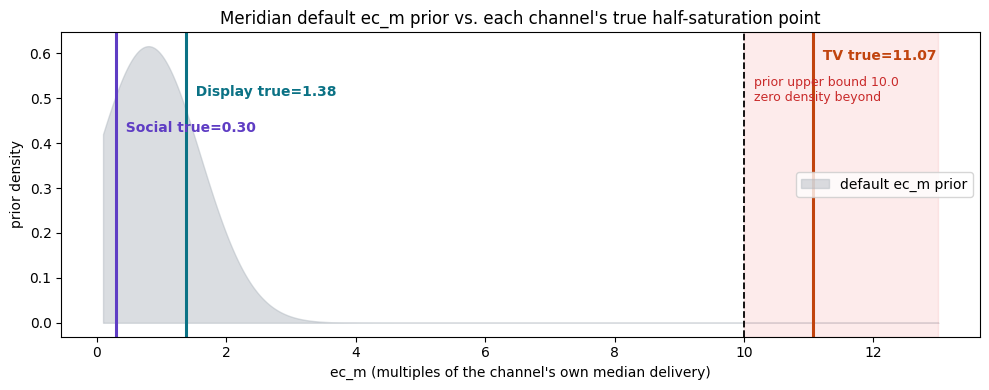

,channel,true_ec_m,in_prior_support,prior_density_at_truth,prior_pct_below_truth
0,TV,11.069,False,0.00000,100.0
1,Display,1.383,True,0.47267,71.2
2,Social,0.297,True,0.50568,9.1


In [3]:
ec_prior = tfp.distributions.TruncatedNormal(0.8, 0.8, 0.1, 10.0)
grid = np.linspace(0.1, 13.0, 900, dtype=np.float32)
dens = ec_prior.prob(grid).numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(grid, dens, color='#adb5bd', alpha=0.45, label='default ec_m prior')
ax.axvline(10.0, color='k', ls='--', lw=1.3)
ax.axvspan(10.0, 13.0, color='#f03e3e', alpha=0.10)
ax.text(10.15, dens.max() * 0.80, 'prior upper bound 10.0\nzero density beyond',
        fontsize=9, color='#c92a2a')

rows = []
for i, ch in enumerate(channels):
    t = float(true_ec_m[i])
    ax.axvline(t, color=CHANNEL_COLORS[ch], lw=2.2)
    ax.text(t, dens.max() * (0.95 - 0.13 * i), f'  {ch} true={t:.2f}',
            color=CHANNEL_COLORS[ch], fontsize=10, fontweight='bold')
    rows.append({
        'channel': ch,
        'true_ec_m': round(t, 3),
        'in_prior_support': bool(0.1 <= t <= 10.0),
        'prior_density_at_truth': round(float(ec_prior.prob(np.float32(t)).numpy()), 5),
        'prior_pct_below_truth': round(float(ec_prior.cdf(np.float32(t)).numpy()) * 100, 1),
    })

ax.set_xlabel('ec_m (multiples of the channel\'s own median delivery)')
ax.set_ylabel('prior density')
ax.set_title('Meridian default ec_m prior vs. each channel\'s true half-saturation point')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()

pd.DataFrame(rows)

## 3. Explanation B: identifiability -- where you sit on your own Hill curve

With the DGP's true `slope_m = 1.0` for every channel, Meridian's Hill
transform is exactly

```
Hill(x) = x / (x + ec)
```

where `x` is population-scaled media and `x = 1` is the channel's own
historical median delivery (so `Hill(1) = 1 / (1 + ec)` is the
"fraction of ceiling captured today" reported throughout this series).

The response entering the KPI is `beta * Hill(x)`. Consider the two regimes:

- **`x` far below `ec`** (an under-delivered channel): `Hill(x) ~ x / ec`, so
  the response is `(beta / ec) * x` -- **only the ratio `beta/ec` affects the
  likelihood.** Any `ec` can fit the data equally well provided `beta` scales
  with it. `ec` is not identified; the posterior is a ridge, and whatever the
  posterior does say is inherited from the prior.
- **`x` at or above `ec`** (a saturated channel): `Hill(x) -> 1 - ec/x`. The
  curve visibly bends inside the observed range, so the data pins where the
  bend is and `ec` is identified on its own.

The local log-log slope makes the regime explicit:

```
d log Hill / d log x  =  ec / (x + ec)  =  1 - Hill(x)
```

A channel at 8% of ceiling has a local elasticity of 0.92 -- almost perfectly
proportional to spend, i.e. indistinguishable from no saturation at all. A
channel at 77% of ceiling has 0.23 -- strongly saturating, and that curvature
is a signal in the data.

This orders the channels by how much the data can say about `ec_m`, and it
predicts a *testable* signature: an `ec`-`beta` ridge in the posterior for the
under-delivered channels and none for Social.

The ordering is a gradient, not a threshold. TV (0.92) and Social (0.23) sit at
the two extremes; Display (0.58) is intermediate -- it has *some* curvature in
range, but as Section 4 shows its `ec_m` posterior still barely contracts, and
Section 5 covers the second, independent reason its fit fails.

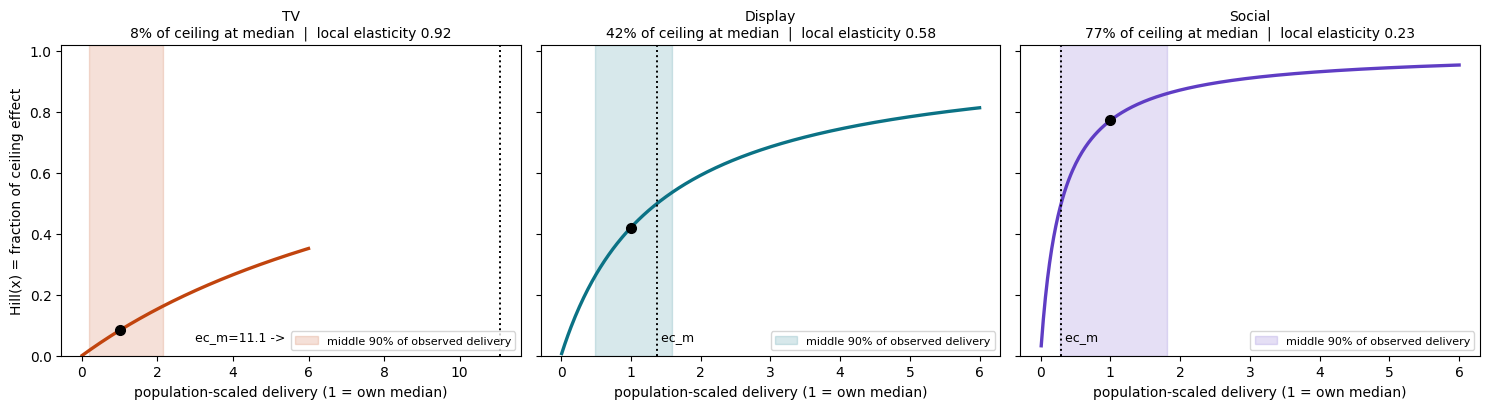

,channel,true_ec_m,ceiling_frac_at_median,local_log_log_slope,obs_p5,obs_p95,regime
0,TV,11.069,0.083,0.917,0.19,2.16,near-linear: ec_m not identified
1,Display,1.383,0.420,0.580,0.48,1.59,intermediate: weak curvature
2,Social,0.297,0.771,0.229,0.29,1.82,saturating: ec_m identified


In [4]:
x_grid = np.linspace(0.01, 6.0, 400)
hill_grid = hill_value(x_grid, true_ec_m)  # (n_points, n_channels)
scaled = sim.transformed_ipc_gtm.numpy()   # (geo, time, channel), x=1 is the median
ceil_all = ceiling_fraction_at_median(true_ec_m)  # one array, avoids scalar casts


def regime_label(elasticity):
  """Coarse read of how much curvature the observed range contains.

  A gradient, not a threshold -- Section 4's contraction ratio is the
  empirical measure; this is the theoretical predictor of it.
  """
  if elasticity > 0.85:
    return 'near-linear: ec_m not identified'
  if elasticity > 0.40:
    return 'intermediate: weak curvature'
  return 'saturating: ec_m identified'


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
summary = []
for i, (ch, ax) in enumerate(zip(channels, axes)):
    col = CHANNEL_COLORS[ch]
    ax.plot(x_grid, hill_grid[:, i], color=col, lw=2.4)
    obs = scaled[:, :, i].ravel()
    obs = obs[obs > 0]
    lo, hi = np.percentile(obs, [5, 95])
    ax.axvspan(lo, hi, color=col, alpha=0.16,
               label='middle 90% of observed delivery')
    ceil_frac = float(ceil_all[i])
    ax.plot([1.0], [ceil_frac], 'o', color='k', ms=7, zorder=5)
    ax.axvline(true_ec_m[i], color='k', ls=':', lw=1.4)
    if true_ec_m[i] <= 6.0:
        ax.text(true_ec_m[i], 0.05, ' ec_m', fontsize=9)
    else:
        ax.text(5.4, 0.05, 'ec_m=%.1f ->' % true_ec_m[i], fontsize=9, ha='right')
    elasticity = 1.0 - ceil_frac
    ax.set_title(f'{ch}\n{ceil_frac*100:.0f}% of ceiling at median  |  '
                 f'local elasticity {elasticity:.2f}', fontsize=10)
    ax.set_xlabel('population-scaled delivery (1 = own median)')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, loc='lower right')
    summary.append({'channel': ch, 'true_ec_m': round(float(true_ec_m[i]), 3),
                    'ceiling_frac_at_median': round(ceil_frac, 3),
                    'local_log_log_slope': round(elasticity, 3),
                    'obs_p5': round(float(lo), 2), 'obs_p95': round(float(hi), 2),
                    'regime': regime_label(elasticity)})
axes[0].set_ylabel('Hill(x) = fraction of ceiling effect')
plt.tight_layout()
plt.show()

pd.DataFrame(summary)

### 3b. The predicted signature: an `ec`-`beta` ridge

If `ec_m` really is unidentified for the under-delivered channels because only
`beta/ec` enters the likelihood, the posterior draws should trace a ridge in
which `ec_m` and `beta_m` rise together. For a channel where `ec_m` is pinned
by curvature, they should be close to independent.

We read this off `ec_alpha_only` rather than `default`, because `default`'s
hard bound at 10.0 truncates TV's ridge and masks the effect -- the informed
prior lets the ridge extend to where the likelihood actually puts it.

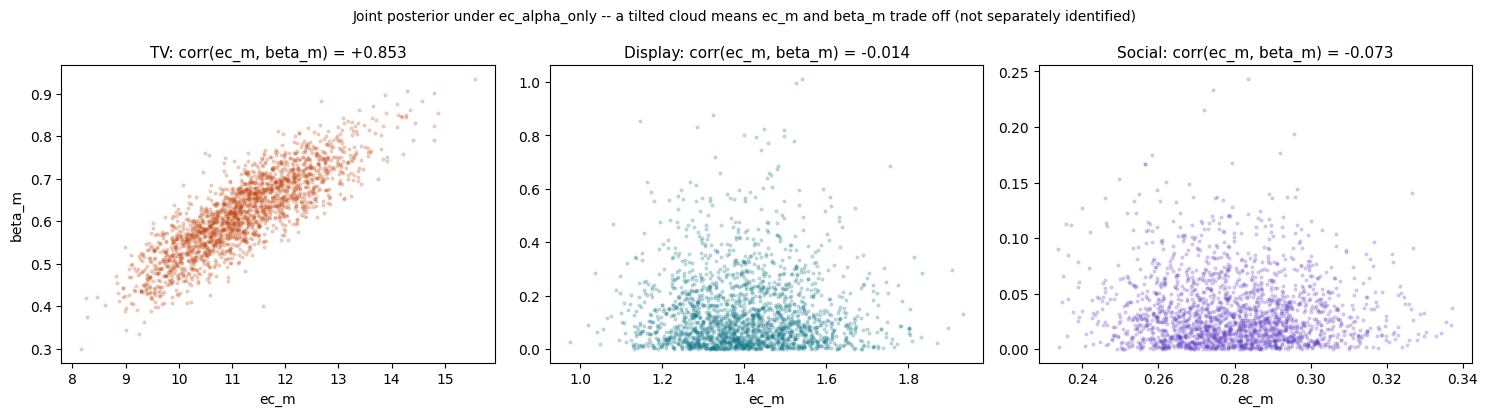

variant,default,ec_alpha_only
channel,,
TV,0.473,0.853
Display,0.025,-0.014
Social,-0.123,-0.073


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ridge_rows = []
for variant in ['default', 'ec_alpha_only']:
    post = idata[variant].posterior
    for i, ch in enumerate(channels):
        ec = post['ec_m'].values[..., i].ravel()
        beta = post['beta_m'].values[..., i].ravel()
        ridge_rows.append({'variant': variant, 'channel': ch,
                           'corr_ec_beta': round(float(np.corrcoef(ec, beta)[0, 1]), 3)})

post = idata['ec_alpha_only'].posterior
for i, (ch, ax) in enumerate(zip(channels, axes)):
    ec = post['ec_m'].values[..., i].ravel()
    beta = post['beta_m'].values[..., i].ravel()
    r = np.corrcoef(ec, beta)[0, 1]
    ax.scatter(ec, beta, s=4, alpha=0.20, color=CHANNEL_COLORS[ch])
    ax.set_title(f'{ch}: corr(ec_m, beta_m) = {r:+.3f}', fontsize=11)
    ax.set_xlabel('ec_m'); ax.set_ylabel('beta_m' if i == 0 else '')
plt.suptitle('Joint posterior under ec_alpha_only -- a tilted cloud means ec_m '
             'and beta_m trade off (not separately identified)', fontsize=10)
plt.tight_layout()
plt.show()

pd.DataFrame(ridge_rows).pivot(index='channel', columns='variant',
                               values='corr_ec_beta').loc[channels]

## 4. Explanation B, quantified: how much did the data actually say?

The cleanest single measure of "did the data inform this parameter" is
**prior-to-posterior contraction** -- the ratio of prior sd to posterior sd for
`ec_m`, per channel. A ratio near 1 means the posterior is just the prior
restated; a large ratio means the likelihood did the work.

Under `default`, all three channels start from the *same* prior, so the
contraction ratios are directly comparable.

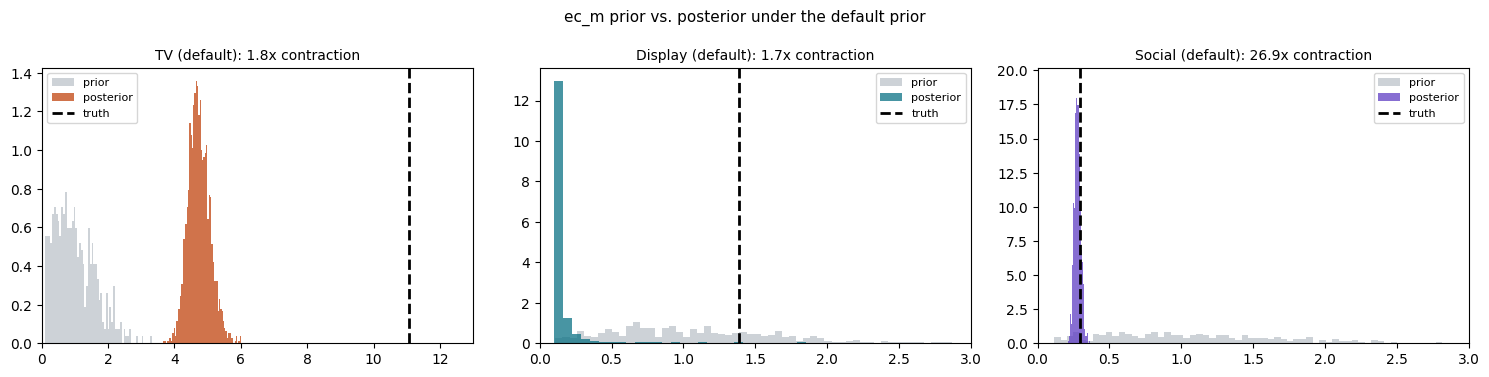

,variant,channel,true_ec_m,prior_sd,post_mean,post_sd,contraction
0,default,TV,11.069,0.603,4.739,0.327,1.84
1,default,Display,1.383,0.584,0.206,0.337,1.73
2,default,Social,0.297,0.587,0.276,0.022,26.93
3,ec_alpha_only,TV,11.069,1.175,11.209,1.070,1.10
4,ec_alpha_only,Display,1.383,0.141,1.402,0.140,1.01
5,ec_alpha_only,Social,0.297,0.030,0.280,0.017,1.72


In [6]:
rows = []
for variant in ['default', 'ec_alpha_only']:
    post, prior = idata[variant].posterior, idata[variant].prior
    for i, ch in enumerate(channels):
        pr = prior['ec_m'].values[..., i].ravel()
        po = post['ec_m'].values[..., i].ravel()
        rows.append({
            'variant': variant, 'channel': ch,
            'true_ec_m': round(float(true_ec_m[i]), 3),
            'prior_sd': round(float(pr.std()), 3),
            'post_mean': round(float(po.mean()), 3),
            'post_sd': round(float(po.std()), 3),
            'contraction': round(float(pr.std() / po.std()), 2),
        })
contraction = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
prior_d = idata['default'].prior['ec_m'].values
post_d = idata['default'].posterior['ec_m'].values
for i, (ch, ax) in enumerate(zip(channels, axes)):
    ax.hist(prior_d[..., i].ravel(), bins=60, density=True, color='#adb5bd',
            alpha=0.6, label='prior')
    ax.hist(post_d[..., i].ravel(), bins=60, density=True,
            color=CHANNEL_COLORS[ch], alpha=0.75, label='posterior')
    ax.axvline(true_ec_m[i], color='k', lw=2, ls='--', label='truth')
    ratio = contraction.query('variant=="default" and channel==@ch')['contraction'].iloc[0]
    ax.set_title(f'{ch} (default): {ratio:.1f}x contraction', fontsize=10)
    ax.set_xlim(0, max(3.0, min(float(true_ec_m[i]) * 1.25, 13)))
    ax.legend(fontsize=8)
plt.suptitle('ec_m prior vs. posterior under the default prior', fontsize=11)
plt.tight_layout()
plt.show()

contraction

**Read the `default` rows.** Social's `ec_m` posterior is roughly **27x**
tighter than its prior. TV's and Display's are under 2x -- barely more than
restating the prior. The data genuinely locates Social's half-saturation point
and genuinely cannot locate the other two, exactly as the Hill-regime argument
in Section 3 predicts.

Note also what happens under `ec_alpha_only`: contraction drops toward 1 for
every channel. That is not a failure -- it means the informed prior is already
so close to what the likelihood would say that there is little left to learn.
The prior is supplying the information the data structurally cannot.

## 5. Explanation C: why Display fails anyway

Display is the control case that kills the simplest story. Its true `ec_m` of
1.383 sits comfortably inside the default prior's bulk (Section 2), so unlike
TV it is not excluded by construction -- and yet the posterior lands at 0.206
and its `roi_m` blows up to ~25x against a true 3.9.

The culprit is a separate pathology already documented in
`model_utils.build_eta_prior`: `eta_m`, the geo-level spread of `beta_gm`,
inflates enormously. Because `beta_gm = exp(beta_m + eta_m * dev_g)` is convex
in `eta_m`, an overstated `eta_m` multiplicatively inflates the
population-weighted average effect -- and hence the derived `roi_m` -- rather
than just widening geo-level uncertainty symmetrically.

In [7]:
rows = []
for variant in ['default', 'ec_alpha_only']:
    post = idata[variant].posterior
    for i, ch in enumerate(channels):
        eta = post['eta_m'].values[..., i].ravel()
        rows.append({'variant': variant, 'channel': ch,
                     'true_eta_m': round(float(true_eta_m[i]), 4),
                     'post_eta_m': round(float(eta.mean()), 3),
                     'inflation_x': (round(float(eta.mean() / true_eta_m[i]), 1)
                                     if true_eta_m[i] > 1e-6 else np.inf)})
eta_tbl = pd.DataFrame(rows)
display(eta_tbl.pivot(index='channel', columns='variant',
                      values=['true_eta_m', 'post_eta_m']).loc[channels])
eta_tbl

true_eta_m               post_eta_m              
variant    default ec_alpha_only    default ec_alpha_only
channel                                                  
TV          0.0456        0.0456      0.089         0.078
Display     0.0008        0.0008      2.310         3.095
Social      0.2775        0.2775      0.309         0.304

,variant,channel,true_eta_m,post_eta_m,inflation_x
0,default,TV,0.0456,0.089,1.9
1,default,Display,0.0008,2.310,2892.2
2,default,Social,0.2775,0.309,1.1
3,ec_alpha_only,TV,0.0456,0.078,1.7
4,ec_alpha_only,Display,0.0008,3.095,3875.1
5,ec_alpha_only,Social,0.2775,0.304,1.1


Display's true `eta_m` is ~0.001 -- essentially no geo-level heterogeneity in
its effect -- and both variants fit it in the 2-3 range. So `eta_m` inflation
is **not** what separates the two variants; it is present either way. What
separates them is that under `ec_alpha_only` the `ec_m` prior holds the
saturation curve in place, and the inflated `eta_m` alone is not enough to
wreck `roi_m` (4.70 recovered vs. a true 3.88). Under `default`, a wrong `ec_m`
*and* an inflated `eta_m` compound into the ~25x `roi_m` blow-up.

Social's true `eta_m` (~0.28) is, by contrast, close to what both variants fit
-- one more respect in which Social is the easy channel.

## 6. Verdict

Social is recoverable under `default` priors for one structural reason, not
because the default prior is well chosen:

1. **It operates at 77% of its ceiling effect.** Its delivery range straddles
   the bend in its own Hill curve, so the curvature needed to locate `ec_m` is
   physically present in the data. The likelihood contracts its `ec_m`
   posterior ~27x versus the prior, and shows no `ec`-`beta` ridge.
2. **TV operates at 8% of ceiling** -- deep in the near-linear regime where
   only `beta/ec` is identified. Its posterior barely contracts (~1.8x) and
   shows a strong `ec`-`beta` ridge (r = +0.85 once the informed prior lets the
   ridge extend). On top of that, its true `ec_m` of 11.07 lies **outside the
   default prior's hard upper bound of 10.0**, so the default model cannot
   represent the truth at all.
3. **Display sits in between (42% of ceiling)** and shows that prior support is
   not sufficient: its truth is well inside the prior's bulk, but a wrong
   `ec_m` compounding with an inflated `eta_m` still destroys `roi_m`.

**The implication for the reach-informed-prior argument.** The one channel that
does not need an informed `ec_m` prior is the one already delivering near
saturation -- i.e. the channel about which nobody had a decision to make. The
channels where the prior changes the answer are exactly the under-delivered
ones, where the data is structurally incapable of locating the saturation
point and *something* must supply it. Meridian's default supplies
`TruncatedNormal(0.8, 0.8, [0.1, 10])` for every channel, which for an
under-reached channel is both weakly informative and centered in the wrong
place -- and, in TV's case here, cannot even reach the right answer.

Put plainly: the default prior is not being tested by Social. It is being
tested by TV, and it fails there for reasons the data alone can never fix.